In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import corner

In [2]:
data = np.load('transient.npy') #loading the data

# BACKGROUND + BURST MODEL 
def model_burst(x, t):
    #model for the transient phenomenon, assumes a constant background and a signal
    #consisting of a burst with an exponential tail
    b, A, alpha, t_0 = x #parameters of the model (varibles for the posterior)
    if t < t_0:
        return b
    else:
        return b + A*np.exp(-alpha*(t-t_0))


def logLikelihood_burst(x):
    #assumes the measurements are subject to gaussian errors
    logL = 0.
    for measure in data:
        mu_i = model_burst(x, measure[0])
        sigma_i = measure[2]
        logL += norm.logpdf(measure[1], loc=mu_i, scale=sigma_i)
    return logL


def ptform_burst(u): #prior distributions

    b = 50.*u[0]
    A = 50.*u[1]
    alpha = np.exp(5*(2*u[2] - 1)) #uniform distribution for log(alpha) in the [-5, 5] range
    t_0 = 100.*u[3]

    return np.array([b, A, alpha, t_0])


# GAUSSIAN MODEL
def model_gauss(x, t):
    #competing model, constant background + gaussian signal
    b, A, sigma_W, t_0 = x
    exponent = -np.pow(t-t_0, 2)/(2*sigma_W*sigma_W)
    return b + A*np.exp(exponent)


def logLikelihood_gauss(x):
    #assumes the measurements are subject to gaussian errors
    logL = 0.
    for measure in data:
        mu_i = model_gauss(x, measure[0])
        sigma_i = measure[2]
        logL += norm.logpdf(measure[1], loc=mu_i, scale=sigma_i)
    return logL


def ptform_gauss(u):

    b = 50.*u[0]
    A = 50.*u[1]
    sigma_W = np.exp(5*(2*u[2] - 1))
    t_0 = 100*u[3]

    return np.array([b, A, sigma_W, t_0])

## Background + burst model

In [17]:
#performing nested sampling with a babkground + burst model 
ndim = 4 #dimension of the parameter space
burst_samp = dynesty.NestedSampler(logLikelihood_burst, ptform_burst, ndim=ndim,  nlive=1000)
burst_samp.run_nested() #running nested sampling

14832it [15:33, 15.89it/s, +1000 | bound: 129 | nc: 1 | ncall: 231155 | eff(%):  6.879 | loglstar:   -inf < -140.648 <    inf | logz: -155.368 +/-  0.124 | dlogz:  0.001 >  1.009]


(<Figure size 1200x1200 with 8 Axes>,
 array([[<Axes: xlabel='$-\\ln X$', ylabel='$x_{1}$'>,
         <Axes: xlabel='$x_{1}$'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='$x_{2}$'>,
         <Axes: xlabel='$x_{2}$'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='$x_{3}$'>,
         <Axes: xlabel='$x_{3}$'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='$x_{4}$'>,
         <Axes: xlabel='$x_{4}$'>]], dtype=object))

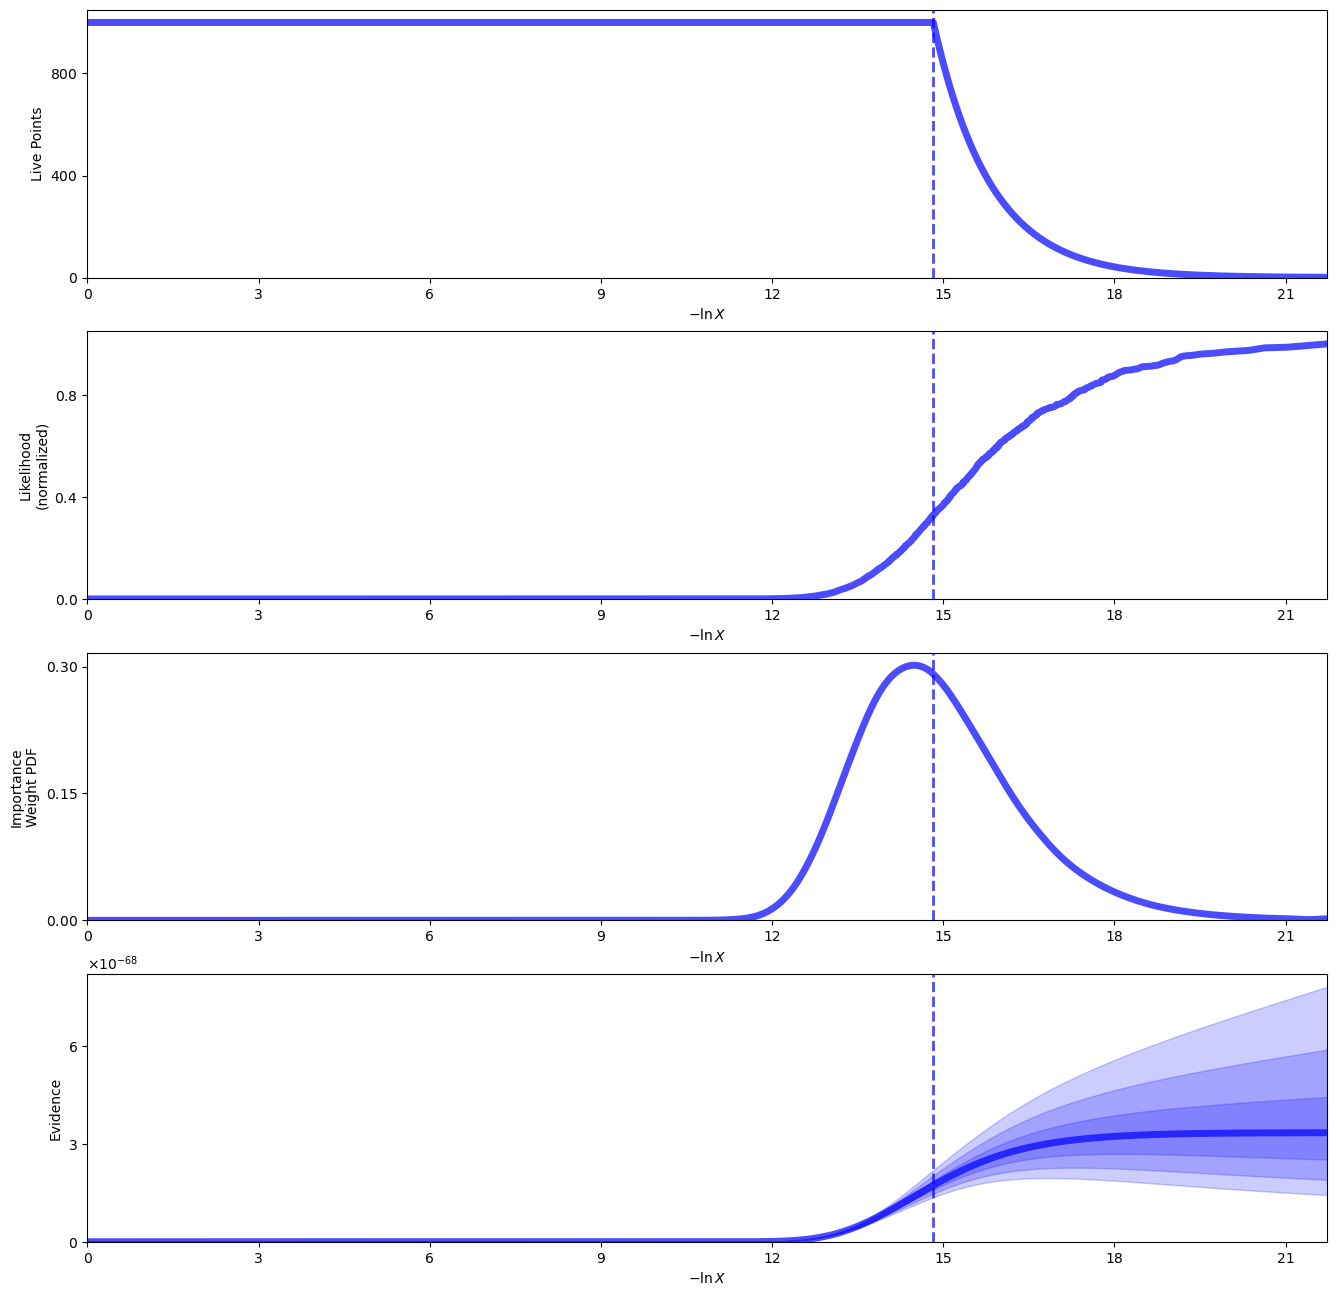

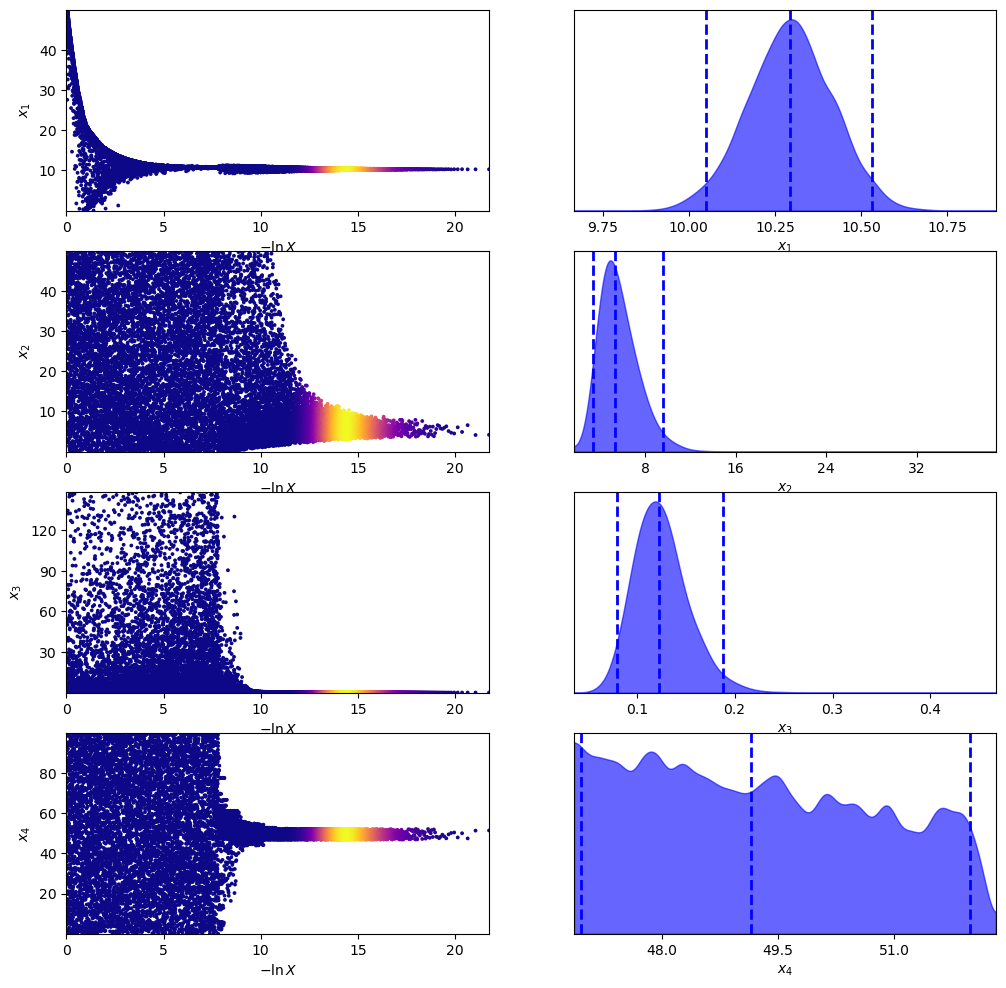

In [18]:
#checking the run by plottting a summary
burst_results = burst_samp.results
dyplot.runplot(burst_results)
dyplot.traceplot(burst_results)

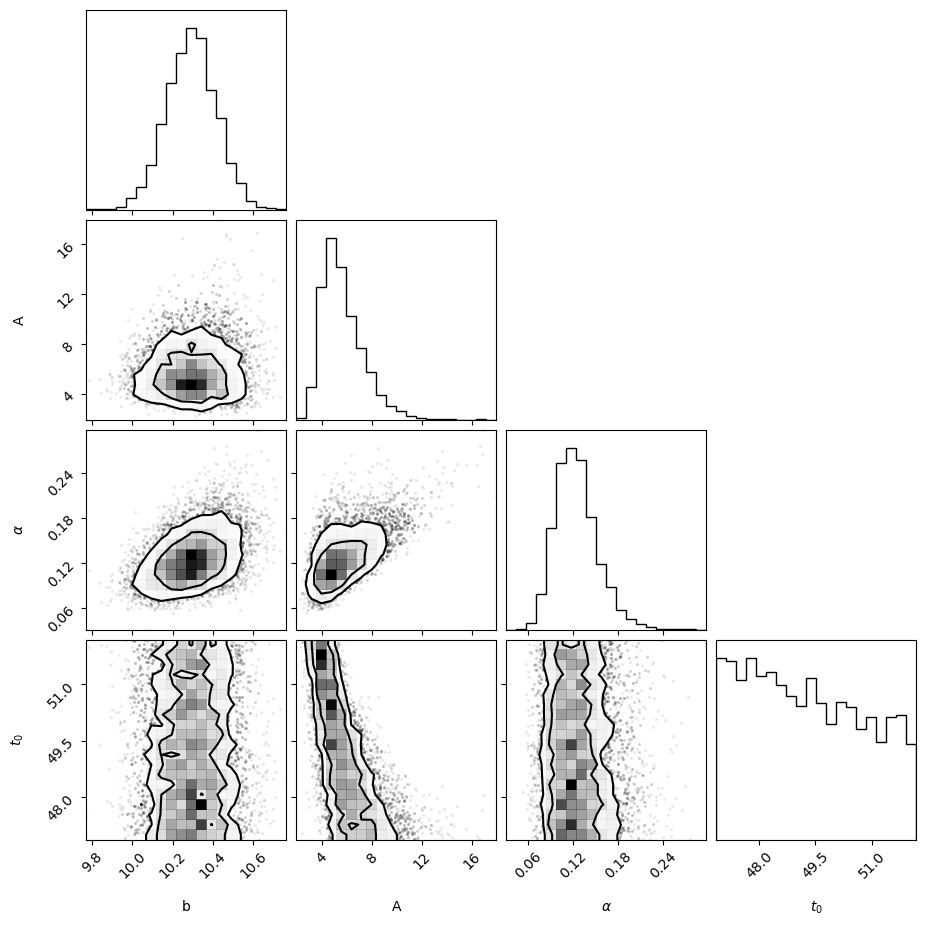

In [19]:

#making a cornel plot of the results
param = ['b', 'A', '$\\alpha$', '$t_{0}$']
weights = np.exp(burst_results.logwt - burst_results.logz[-1])   
resampled_burst = dyfunc.resample_equal(burst_results.samples, weights)
corner_fig = corner.corner(resampled_burst, labels=param, levels=[0.68, 0.90])

In [20]:
# getting the medians and 90% credible regions for each parameter
median_param = []
credible_reg = []
labels = ['b', 'A', 'alpha', 't_0']
for sample in burst_results.samples.T:
    credible_reg.append(dyfunc.quantile(sample, [0.05, 0.95], weights=weights))

for i in range(len(param)):
    median = (np.median(resampled_burst[:, i]))
    median_param.append(median)
    print(f"{labels[i]} = {median_param[i]:.2f} [{credible_reg[i][0]:.2f}, {credible_reg[i][1]:.2f}] (90% CL)")

b = 10.29 [10.09, 10.49] (90% CL)
A = 5.36 [3.60, 8.75] (90% CL)
alpha = 0.12 [0.09, 0.17] (90% CL)
t_0 = 49.15 [47.06, 51.83] (90% CL)


## Background + gaussian model

In [13]:
#performing nested sampling with a babkground + gaussian model 
gauss_samp = dynesty.NestedSampler(logLikelihood_gauss, ptform_gauss, ndim=ndim, nlive=1000)
gauss_samp.run_nested()

9007it [11:20,  1.23it/s, bound: 83 | nc: 179 | ncall: 159452 | eff(%):  5.649 | loglstar:   -inf < -172.655 <    inf | logz: -183.136 +/-  0.093 | dlogz: 27.812 >  1.009]    /home/gabriele/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/home/gabriele/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex pos

(<Figure size 1200x1200 with 8 Axes>,
 array([[<Axes: xlabel='$-\\ln X$', ylabel='$x_{1}$'>,
         <Axes: xlabel='$x_{1}$'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='$x_{2}$'>,
         <Axes: xlabel='$x_{2}$'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='$x_{3}$'>,
         <Axes: xlabel='$x_{3}$'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='$x_{4}$'>,
         <Axes: xlabel='$x_{4}$'>]], dtype=object))

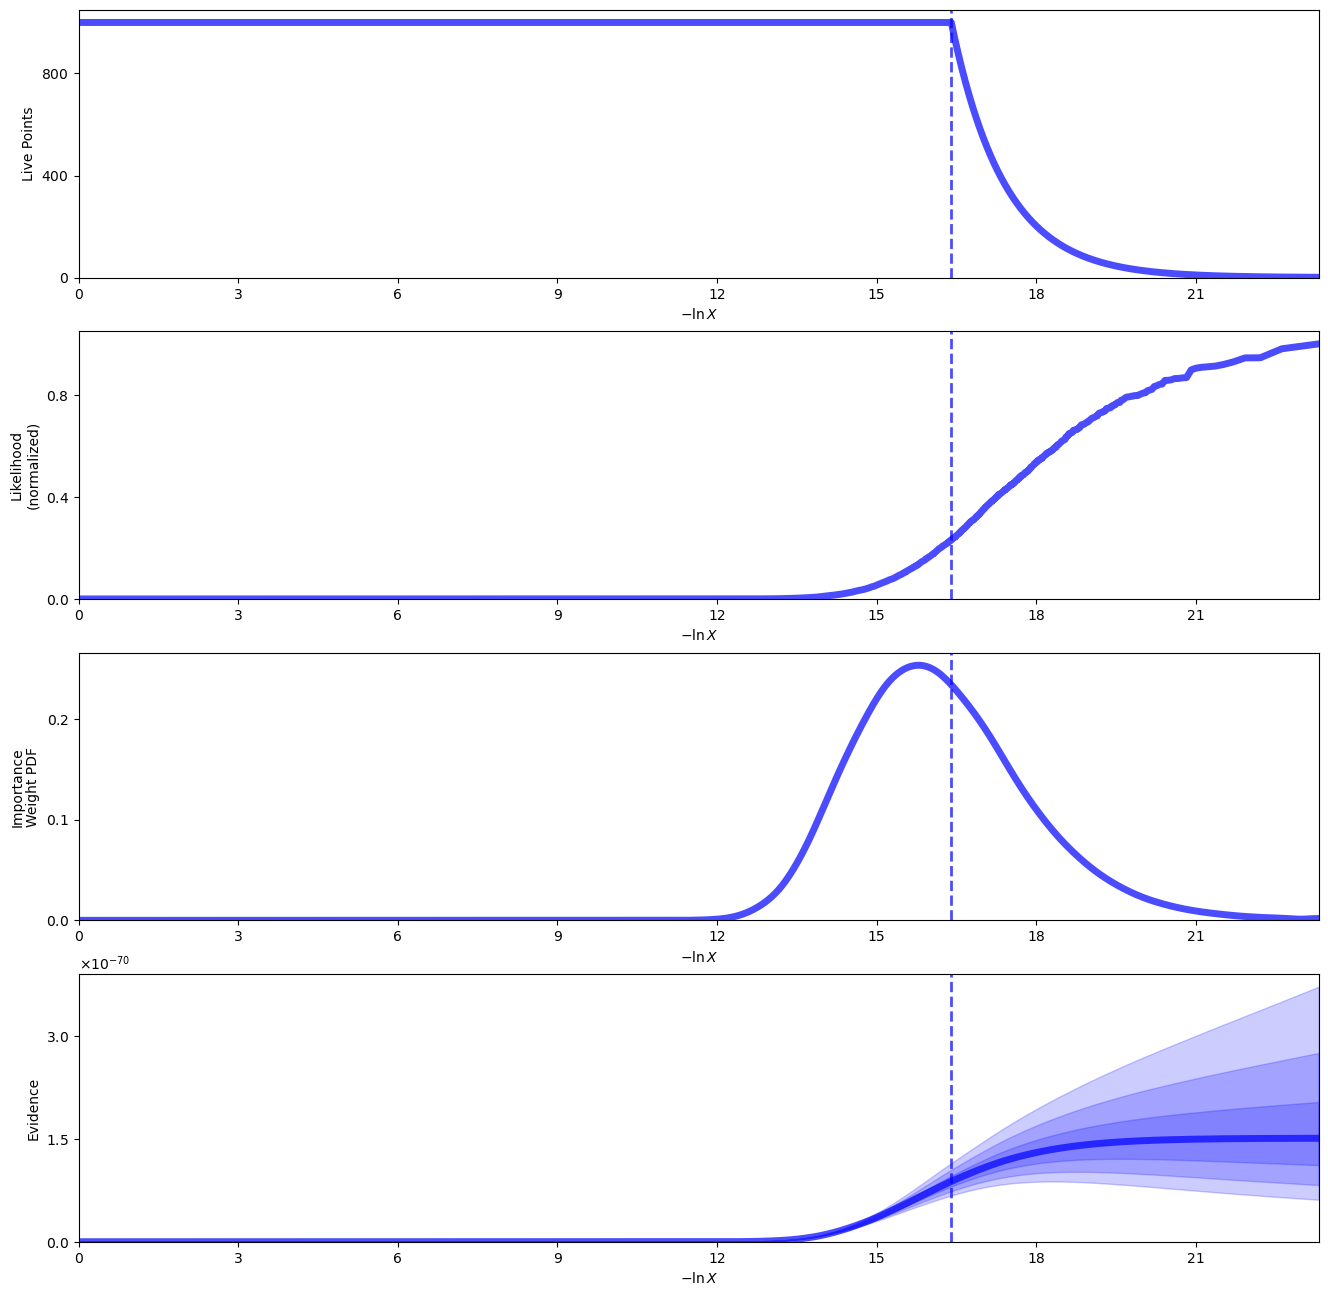

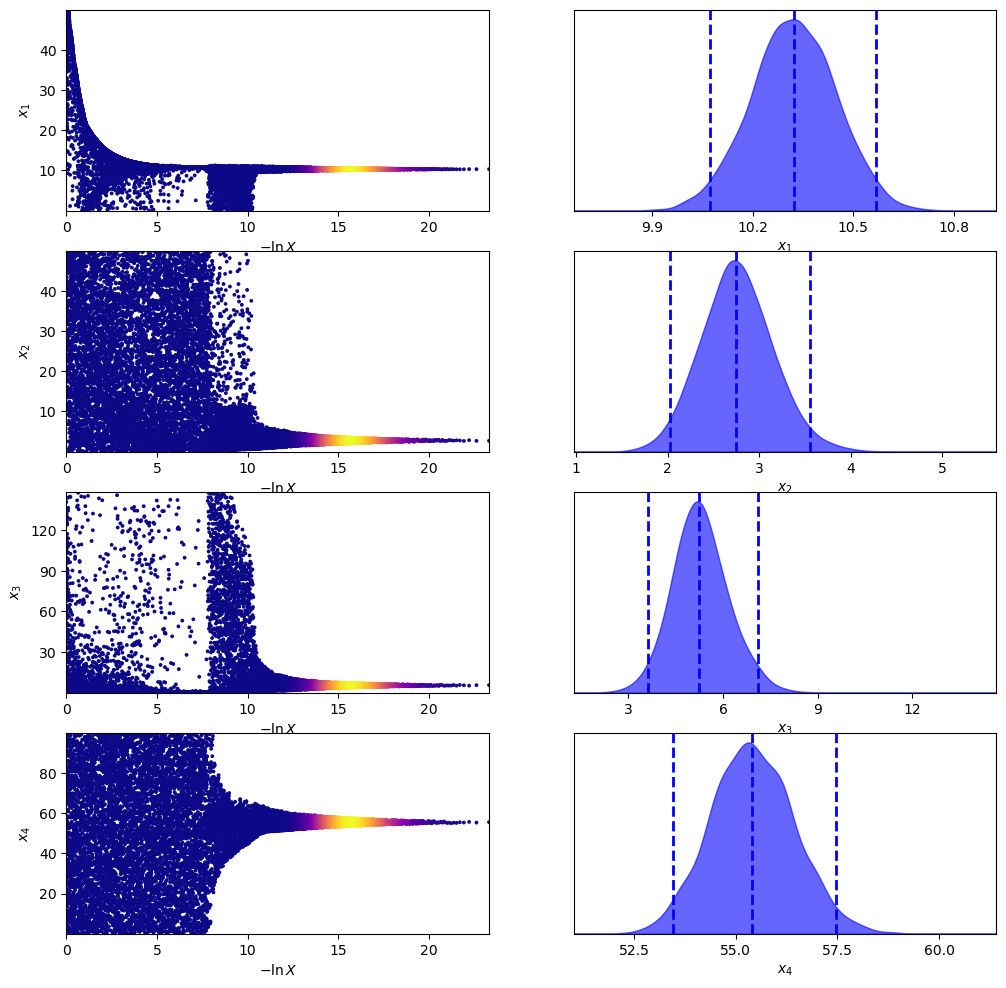

In [14]:
#check plots
gauss_results = gauss_samp.results
dyplot.runplot(gauss_results)
dyplot.traceplot(gauss_results)

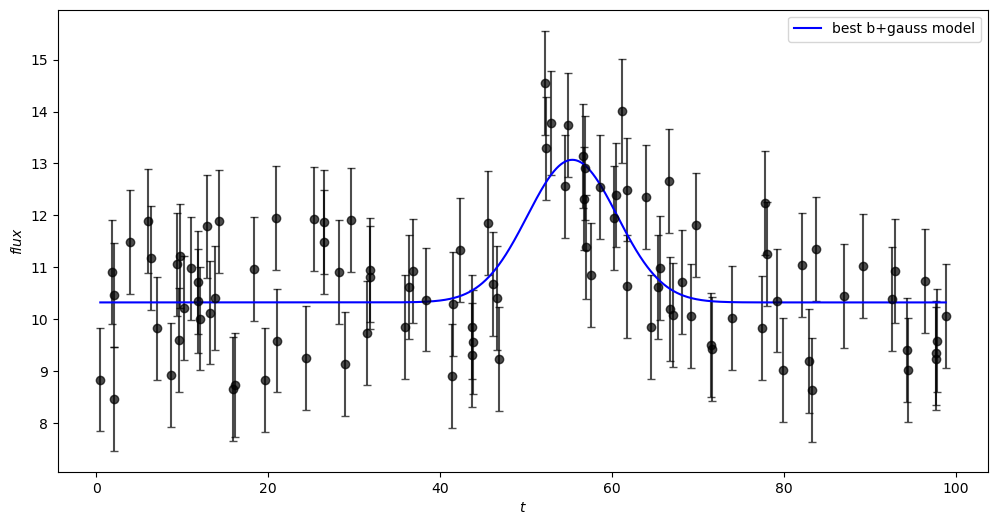

In [16]:
# we plot the b+gauss model with the medians of the marginalized posteriors (along with the data)

weights_g = np.exp(gauss_results.logwt - gauss_results.logz[-1])   
resampled_burst = dyfunc.resample_equal(gauss_results.samples, weights_g) #getting the unweighted samples

median_param_g = [np.median(resampled_burst[:, i]) for i in range(4)] #medians

t_vals = data[:, 0]
flux = data[:, 1]
errs = data[:, 2]
t_grid = np.linspace(np.min(t_vals), np.max(t_vals), 10000)

#plotting the results
plt.figure(figsize=(12, 6))
plt.errorbar(t_vals, flux, yerr=errs, capsize=3, fmt='o', c='black', alpha=0.7)
plt.xlabel('$t$')
plt.ylabel('$flux$')
plt.plot(t_grid, model_gauss(median_param_g, t_grid), c='blue', label='best b+gauss model')
plt.legend()

## Model Comparison

We compare the two models by computing the odds ratio $O_{21}$. If we set the prior $P(M) = 0.5$ for both models then $O_{21}$ is equal to the Bayes factor $B$ 

In [21]:
# we compare the two models by computing the Bayes factor
# 2 = background + burst
# 1 = backgorund + gaussian
evidence_burst = np.exp(burst_samp.results.logz[-1]) #getting the evidences
evidence_gauss = np.exp(gauss_samp.results.logz[-1])

B = evidence_burst/evidence_gauss #Bayes factor
print(f"B = {B:.2f}")

B = 221.64


Considering the Jeffrey's scale, we claim to have DECISIVE EVIDENCE in favour of the 'BACKGORUND + BURST' model